# opt5 — add a bounding volume hierarchy

Numbers: `bench/results/incremental.log`, sprc01, median of 3.

Speedup shown on the two mesh facets only; the piano room and globe are
unchanged at 1.01× and 1.00×.

**Kernel:** the `mp1` conda environment.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_figures_dir(start: Path | None = None) -> Path:
    """Locate <repo>/report/figures. A notebook has no __file__, so walk up
    from the working directory instead."""
    here = (start or Path.cwd()).resolve()
    for cand in (here, *here.parents):
        if (cand / "bench").is_dir() and (cand / "main.cpp").is_file():
            out = cand / "report" / "figures"
            out.mkdir(parents=True, exist_ok=True)
            return out
    out = here / "figures"          # fallback: beside the notebook
    out.mkdir(parents=True, exist_ok=True)
    return out


OUT = find_figures_dir()
print("writing to", OUT)

writing to /home/yikang/cs598ape/hw1/report/figures


## Measured data

Edit these to re-render.

In [2]:
CONFIGS = ["Before (opt4)", "Bounding volume hierarchy"]
WL = ["Pianoroom\n1000×1000", "Globe\n1000×1000", "Sphere mesh\n100×100", "Elephant\n100×100"]
TIMES = np.array([
    [1.68193, 1.660646],
    [1.676802, 1.672398],
    [0.819879, 0.003438],
    [30.223227, 0.114812],
])

BAR_W = 0.776       # bar width, tuned so bars match the other figures
SPEEDUP = [2, 3]          # facet indices that get the dashed line and arrow

## Style

In [3]:
SLOW, FAST = "#343535", "#ffb830"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "Nimbus Roman",
                   "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2,
    "ytick.color": INK2, "ytick.labelsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "legend.frameon": False, "figure.dpi": 200,
})

## The figure

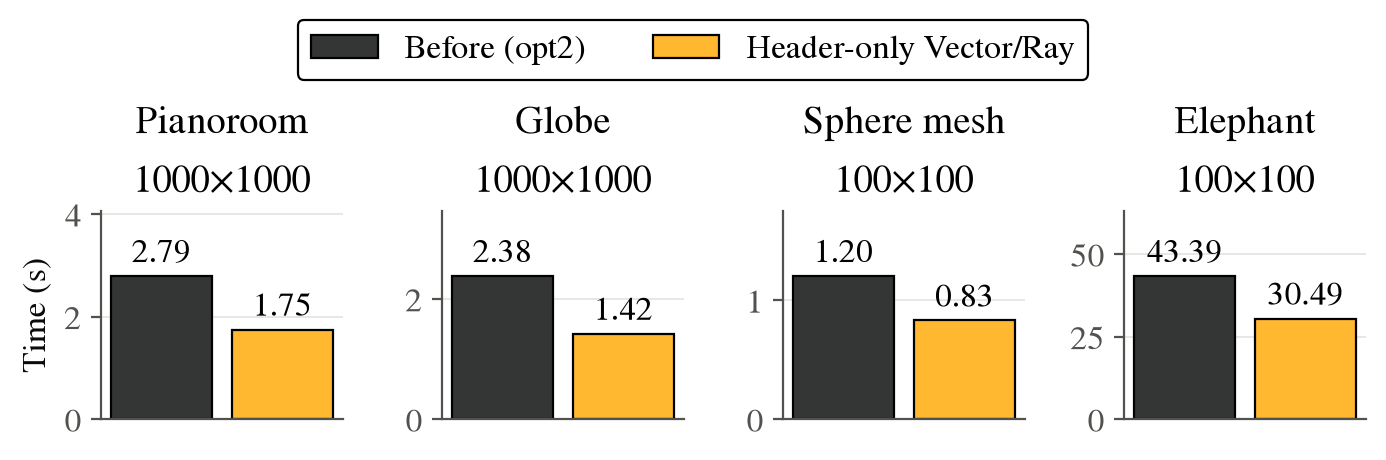

In [4]:
def make_figure(width=7.0, height=2.0):
    fig, axes = plt.subplots(1, len(WL), figsize=(width, height))
    axes = np.atleast_1d(axes)

    for i, (ax, name, row) in enumerate(zip(axes, WL, TIMES)):
        bars = ax.bar(np.arange(2), row, BAR_W, color=[SLOW, FAST],
                      edgecolor="black", linewidth=0.8)
        ax.set_ylim(0, row.max() * 1.45)
        ax.set_xlim(-0.5, 1.5)
        ax.set_xticks([])
        ax.set_title(name, fontsize=14)
        ax.grid(axis="x", visible=False)

        for rect, v in zip(bars, row):
            ax.annotate(f"{v:.2f}" if v >= 0.01 else f"{v:.4f}",
                        xy=(rect.get_x() + rect.get_width() / 2, v),
                        xytext=(0, 2), textcoords="offset points",
                        ha="center", va="bottom", fontsize=12, color="black")

        # The speedup is drawn only where it reads well: a near-1.0 ratio gives a
        # stub of an arrow and a label that crowds the bar's own value.
        if i not in SPEEDUP:
            continue

        ax.plot([0, bars[-1].get_x() + bars[-1].get_width()], [row[0], row[0]],
                linestyle=(0, (3.7, 1.6)), color=INK, linewidth=1.0, zorder=3)
        r = row[0] / row[1]
        label = f"{r:,.0f}×" if r >= 100 else f"{r:.2f}×"
        ax.annotate("", xy=(1, row[1] * 1.05), xytext=(1, row[0] * 0.96),
                    arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.0,
                                    shrinkA=0, shrinkB=13, mutation_scale=11),
                    zorder=3)
        ax.annotate(label, xy=(1, row[0]), xytext=(0, 14),
                    textcoords="offset points", ha="center", va="top",
                    fontsize=12, fontweight="bold", color=INK, zorder=4,
                    bbox=dict(boxstyle="square,pad=0.15", facecolor="none",
                              edgecolor="none"))

    axes[0].set_ylabel("Time (s)", fontsize=12)
    handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor="black", linewidth=0.8)
               for c in (SLOW, FAST)]
    leg = fig.legend(handles, CONFIGS, loc="upper center", ncols=2,
                     bbox_to_anchor=(0.5, 1.16), fontsize=12,
                     frameon=True, edgecolor="black", framealpha=1.0)
    leg.get_frame().set_linewidth(0.8)
    fig.tight_layout(w_pad=1.5)
    return fig


fig = make_figure()

## Save

Writes `figures/opt5_bvh.pdf` and `.png`.

In [5]:
paths = []
for ext in ('pdf', 'png'):
    p = OUT / f'opt5_bvh.{ext}'
    fig.savefig(p, bbox_inches='tight')
    paths.append(p)

for p in paths:
    print(f'{p}  ({p.stat().st_size / 1024:.1f} KiB)')

/home/yikang/cs598ape/hw1/report/figures/opt3_inline_vector.pdf  (10.0 KiB)
/home/yikang/cs598ape/hw1/report/figures/opt3_inline_vector.png  (59.0 KiB)
